In [2]:
# 경고 메시지 무시
import warnings
warnings.filterwarnings(action='ignore') 

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import csv
import folium
import datetime
import seaborn as sns
import scipy as sp
import statsmodels.formula.api as smf
import networkx as nx
import missingno as msno
import os
import sys
import urllib.request
import time
import json
import plotly.express as px
import re
import sklearn.metrics as metrics

from sklearn.decomposition import PCA
from sklearn.datasets import load_iris, load_wine, load_breast_cancer, load_diabetes
from folium.plugins import HeatMap 
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from dateutil.relativedelta import relativedelta
from sklearn.cluster import KMeans    
from yellowbrick.cluster import KElbowVisualizer
from scipy.cluster.hierarchy import dendrogram, linkage
from mpl_toolkits.mplot3d import Axes3D
from operator import itemgetter
from PIL import Image
from collections import Counter
from wordcloud import WordCloud
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import r2_score, ConfusionMatrixDisplay, confusion_matrix, accuracy_score, silhouette_score
from sklearn.neighbors import KNeighborsClassifier

# plt.rc('font', family='malgun gothic')
# plt.rcParams['axes.unicode_minus']=False  # '- 표시
plt.rc('font',family='D2CodingLigature Nerd Font')

# 와인 데이터셋 KNN 분류분석

## 1. 와인 데이터셋 로드

In [ ]:
wine = load_wine()
x, y = wine.data, wine.target
wine

{'data': array([[1.423e+01, 1.710e+00, 2.430e+00, ..., 1.040e+00, 3.920e+00,
         1.065e+03],
        [1.320e+01, 1.780e+00, 2.140e+00, ..., 1.050e+00, 3.400e+00,
         1.050e+03],
        [1.316e+01, 2.360e+00, 2.670e+00, ..., 1.030e+00, 3.170e+00,
         1.185e+03],
        ...,
        [1.327e+01, 4.280e+00, 2.260e+00, ..., 5.900e-01, 1.560e+00,
         8.350e+02],
        [1.317e+01, 2.590e+00, 2.370e+00, ..., 6.000e-01, 1.620e+00,
         8.400e+02],
        [1.413e+01, 4.100e+00, 2.740e+00, ..., 6.100e-01, 1.600e+00,
         5.600e+02]], shape=(178, 13)),
 'target': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,

## 2. 데이터를 훈련 세트와 테스트 세트로 나눔 (8:2 비율)

In [5]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

## 3. KNN 모델 생성 (이웃 수 k=3)

In [6]:
knn = KNeighborsClassifier(n_neighbors=3)

## 4. 모델 훈련

In [7]:
knn.fit(x_train, y_train)

,n_neighbors,3
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


## 5. 테스트 세트에 대한 예측 및 결과 출력

In [8]:
y_pred = knn.predict(x_test)
print(f"예측값: {y_pred}")
print(f"실제값: {y_test}")

예측값: [2 0 2 0 1 0 1 2 0 0 2 2 0 1 0 1 1 1 0 1 0 1 2 2 1 2 1 2 1 0 0 1 2 0 0 0]
실제값: [0 0 2 0 1 0 1 2 1 2 0 2 0 1 0 1 1 1 0 1 0 1 1 2 2 2 1 1 1 0 0 1 2 0 0 0]


## 6. 정확도 출력

In [9]:
accuracy = accuracy_score(y_test, y_pred)
print(f'정확도: {accuracy:.2f}') 

정확도: 0.81


## 7. 시각화 (특성이 많으므로 처음 2개의 특성만 사용)

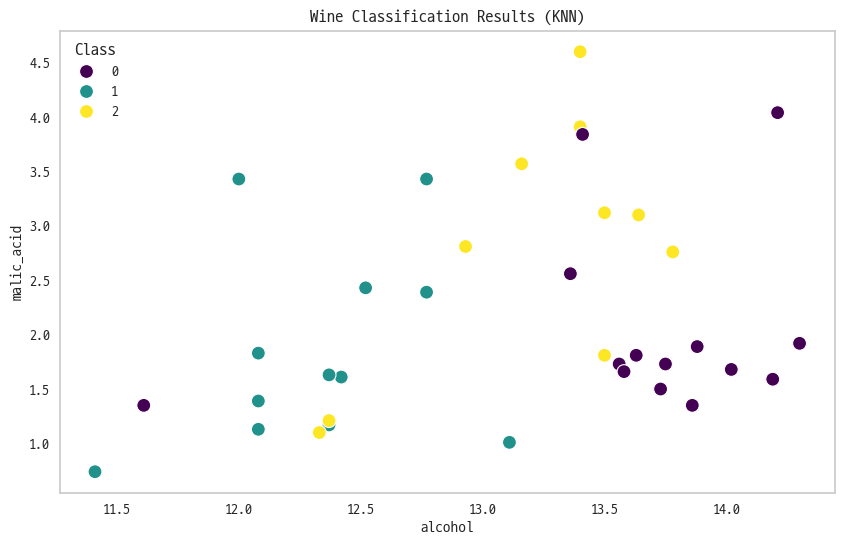

In [10]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=x_test[:, 0], y=x_test[:, 1], hue=y_pred, palette='viridis', s=100)
plt.xlabel(wine.feature_names[0]) # Alcohol
plt.ylabel(wine.feature_names[1]) # Malic acid
plt.title('Wine Classification Results (KNN)')
plt.legend(title='Class')
plt.grid(False)
plt.show()

## 8. 새로운 데이터로 분류 예측

In [11]:
# 와인의 13개 특성 수치를 임의로 입력 
new_wine_data = np.array([[13.71, 1.86, 2.36, 16.6, 101.0, 2.61, 2.88, 0.27, 1.69, 3.8, 1.11, 4.0, 1035.0]])
p_y = knn.predict(new_wine_data)

# 예측된 분류번호 출력 (0, 1, 2 중 하나)
print(f"Predicted class: {p_y} (Wine Name: {wine.target_names[p_y][0]})")

Predicted class: [0] (Wine Name: class_0)


# 개선된 와인 분석 코드 (표준화 + PCA 적용)

## 1. 표준화, 주성분분석(PCA)

PCA 적용 후 정확도: 0.97


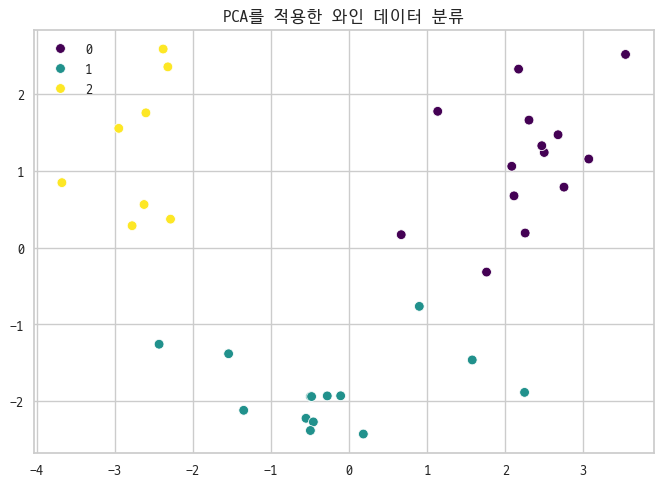

In [13]:
# 데이터셋 로드
wine = load_wine()
x = wine.data

# 1. 데이터 표준화
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

# 2. PCA를 이용해 13개 변수를 2개의 주성분으로 압축
pca = PCA(n_components=2)
x_pca = pca.fit_transform(x_scaled)

# 3. 훈련/테스트 데이터 분리
x_train_p, x_test_p, y_train, y_test = train_test_split(x_pca, y, test_size=0.2, random_state=42)

# 4. KNN 학습 및 예측
knn_pca = KNeighborsClassifier(n_neighbors=3)
knn_pca.fit(x_train_p, y_train)

# 정확도 확인
print(f"PCA 적용 후 정확도: {knn_pca.score(x_test_p, y_test):.2f}")

# 시각화 (이제 13개가 아닌 압축된 2개 축으로 완벽하게 표현 가능)
sns.scatterplot(x=x_test_p[:, 0], y=x_test_p[:, 1], hue=y_test, palette='viridis')
plt.title('PCA를 적용한 와인 데이터 분류')
plt.show()

## 2. 새로운 데이터로 예측

In [15]:
# 1. 새로운 와인 데이터 정의 (13개의 특성 수치)
new_data = np.array([[13.5, 1.8, 2.4, 17.5, 110.0, 2.5, 2.7, 0.3, 1.5, 4.0, 1.1, 3.5, 1000.0]])

# 2. 표준화와 주성분
new_data_scaled = scaler.transform(new_data)
new_data_pca = pca.transform(new_data_scaled)  ## fit_transform이 아니라 transform만 사용

# 3. 예측
predicted_class = knn_pca.predict(new_data_pca)
predicted_name = wine.target_names[predicted_class][0]

print(f"예측된 와인 클래스: {predicted_class}")
print(f"와인 종류 이름: {predicted_name}")

예측된 와인 클래스: [0]
와인 종류 이름: class_0


## 3. 최적의 k값 찾기

최고 정확도: 1.0000 (at K = 2)


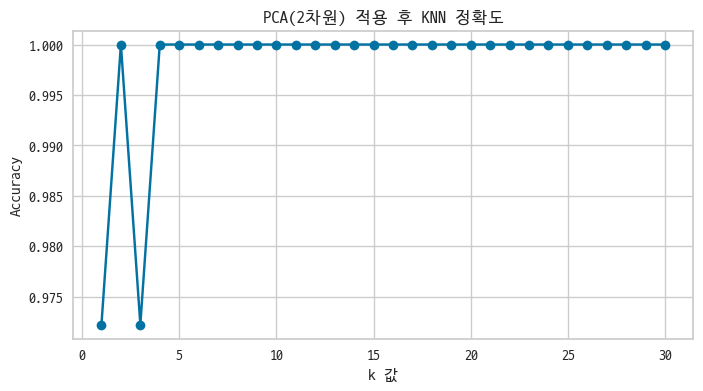

In [19]:
k_range = range(1, 31)
accuracies = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(x_train_p, y_train)
    y_pred = knn.predict(x_test_p)
    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)

print(f"최고 정확도: {max(accuracies):.4f} (at K = {np.argmax(accuracies) + 1})")

# 그래프
plt.figure(figsize=(8, 4))
plt.plot(k_range, accuracies, marker='o')
plt.xlabel("k 값")
plt.ylabel("Accuracy")
plt.title("PCA(2차원) 적용 후 KNN 정확도")
plt.grid(True)
plt.show()
